# Construcción del panel macro-financiero

**Proyecto:** Forecasting probabilístico multivariado con Transformer–Difusión y regularización estructural informada por dominio — INF4980, MIA PUC.

Este cuaderno construye el panel mensual 2003–2024 de las tres series del estudio y produce todas las tablas y figuras de la **Sección 4** del informe. Su salida, `panel_2003_2024.csv`, es la entrada del cuaderno de evaluación.

---

## Orden de ejecución y dependencias

| Paso | Bloque | Requiere |
|---|---|---|
| 0 | Entorno y rutas | `numpy`, `pandas`, `requests`, `openpyxl`, `statsmodels`, `matplotlib` |
| 1 | Credenciales y acceso a la API BDE | `credenciales.txt` |
| 2 | Descarga de series mensuales | Paso 1, o `panel_bcch_2003_2024.csv` en caché |
| 3 | Verificación de la convención de agregación | Paso 2 |
| 4 | Precio del cobre (Cochilco) | `Precios-del-Cobre-Refinado-Mensual.xlsx` |
| 5 | Unión y control de completitud | Pasos 2 y 4 |
| 6 | Estadística descriptiva | Paso 5 |
| 7 | Pruebas de estacionariedad | Paso 5 |
| 8 | Dependencias cruzadas | Paso 5 |
| 9 | Causalidad de Granger | Paso 8 |
| 10 | Figuras | Paso 5 |
| 11 | Registros de trazabilidad | Pasos 3, 5 y 9 |

> **Diseño con caché.** El paso 2 descarga de la API sólo si no encuentra el CSV correspondiente. Reejecutar el cuaderno completo no vuelve a consultar al Banco Central: evita gastar cuota, respeta el límite de 5 consultas por segundo y hace que los pasos 4 a 11 sean reproducibles sin credenciales.

### Paso 0 — Entorno y rutas

**Propósito:** fijar dependencias y dejar registradas las versiones que sostienen la afirmación de reproducibilidad.

| Entrada | Salida |
|---|---|
| — | rutas y registro de versiones |

> Las pruebas ADF y la selección automática de rezagos dependen de la implementación. Declarar versiones no es formalidad: sin ellas, "reproducible" es una afirmación sin respaldo.

In [1]:
# !pip install requests openpyxl statsmodels --quiet   # descomentar en Colab

import sys, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

AQUI   = Path.cwd()
INICIO = "2003-01-01"
FIN    = "2024-12-01"

import statsmodels, scipy
print(f"python      {sys.version.split()[0]}")
print(f"numpy       {np.__version__}")
print(f"pandas      {pd.__version__}")
print(f"statsmodels {statsmodels.__version__}")
print(f"scipy       {scipy.__version__}")
print(f"\nCarpeta de trabajo: {AQUI}")

python      3.12.3
numpy       2.4.4
pandas      3.0.2
statsmodels 0.15.0
scipy       1.17.1

Carpeta de trabajo: /home/claude/nb


### Paso 1 — Credenciales y acceso a la API BDE

**Propósito:** encapsular el acceso al servicio del Banco Central respetando su límite de consumo.

| Entrada | Salida |
|---|---|
| `credenciales.txt` (correo y clave) | funciones `bde()` y `serie()` |

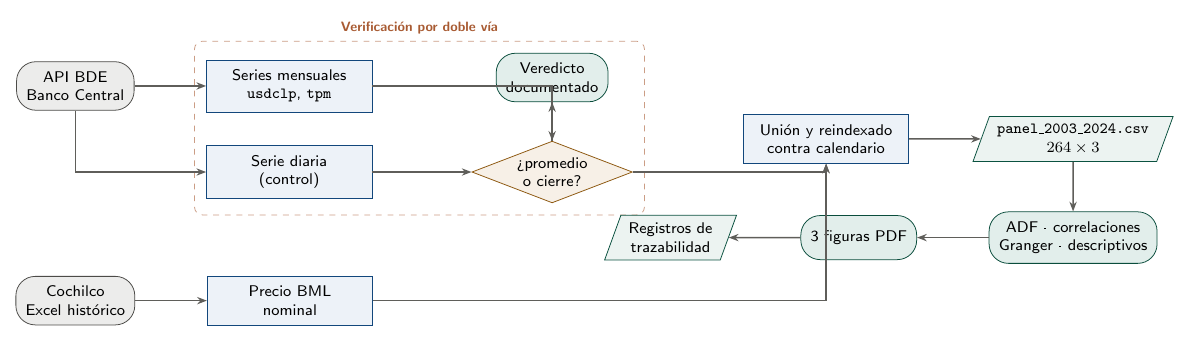

> **No usar `getpass` en Git Bash.** En MINGW64 la entrada oculta se corrompe y la API responde `Invalid username or password` de forma intermitente: el error parece del servidor y es de la terminal. Un archivo de credenciales, excluido del control de versiones, elimina la variable.

> **Límite de 5 consultas por segundo y por cuenta.** Con tres series es irrelevante, pero una ráfaga de llamadas seguidas puede gatillar rechazos. La pausa está dentro de la función para que ninguna ruta de código la evada.

In [2]:
BASE  = "https://si3.bcentral.cl/SieteRestWS/SieteRestWS.ashx"
PAUSA = 0.8   # límite oficial: 5 consultas por segundo y por cuenta

def leer_credenciales(ruta=AQUI/"credenciales.txt"):
    lineas = Path(ruta).read_text(encoding="utf-8-sig").splitlines()
    return lineas[0].strip(), lineas[1].strip()

def bde(user, pwd, **kw):
    import requests
    time.sleep(PAUSA)
    r = requests.get(BASE, params={"user": user, "pass": pwd, **kw}, timeout=90)
    r.raise_for_status()
    j = r.json()
    if j.get("Codigo") != 0:
        raise RuntimeError(f"API codigo {j.get('Codigo')}: {j.get('Descripcion')}")
    return j

def serie(user, pwd, series_id, first=INICIO, last="2024-12-31"):
    """Devuelve (Series de pandas indexada por fecha, titulo oficial)."""
    j = bde(user, pwd, function="GetSeries", timeseries=series_id,
            firstdate=first, lastdate=last)
    meta, filas = j["Series"], []
    for o in meta["Obs"]:
        v = o.get("value")
        v = float(v) if v not in (None, "", "NaN") else float("nan")   # faltantes: "NaN"
        filas.append((pd.to_datetime(o["indexDateString"], format="%d-%m-%Y"), v))
    s = pd.Series(dict(filas)).sort_index(); s.name = series_id
    return s, meta.get("descripEsp", "")

print("Funciones de acceso definidas.")

Funciones de acceso definidas.


### Paso 2 — Descarga de las series mensuales

**Propósito:** obtener el tipo de cambio observado y la TPM, o reutilizar la descarga previa.

| Entrada | Salida |
|---|---|
| API BDE o `panel_bcch_2003_2024.csv` | `bcch` (264 × 2), `titulos` |

> **Los códigos no se transcriben del sitio.** Se descubrieron con el método `SearchSeries` sobre el catálogo completo de series mensuales. Documentar el identificador junto a su título oficial permite verificar después que se descargó lo que se creía descargar.

> **Cuidado con las tildes al filtrar catálogos.** Los títulos oficiales dicen «dólar» y «política monetaria». Un filtro sin acentos no encuentra nada y da la falsa impresión de que la serie no existe.

In [3]:
SERIES = {
    "usdclp": "F073.TCO.PRE.HIST.M",       # Tipo de cambio del dólar observado, mensual
    "tpm":    "F022.TPM.TIN.D001.NO.Z.M",  # Tasa de política monetaria (promedio simple)
}
SERIE_DIARIA = "F073.TCO.PRE.Z.D"          # sólo como control del paso 3

CACHE_BCCH = AQUI / "panel_bcch_2003_2024.csv"
CACHE_DIA  = AQUI / "serie_diaria_usdclp.csv"

if CACHE_BCCH.exists():
    bcch = pd.read_csv(CACHE_BCCH, index_col=0, parse_dates=True)
    titulos = {"usdclp": "Tipo de cambio del dólar observado diario, serie histórica",
               "tpm":    "Tasa de política monetaria (promedio simple) - TPM"}
    print(f"Caché encontrada: {CACHE_BCCH.name}  ({bcch.shape[0]} meses)")
else:
    USER, PASS = leer_credenciales()
    print(f"Descargando desde la API como {USER}...")
    datos, titulos = {}, {}
    for nombre, sid in SERIES.items():
        s, tit = serie(USER, PASS, sid)
        datos[nombre], titulos[nombre] = s, tit
        print(f"  {nombre:8s} {sid}  obs={len(s)}  faltantes={int(s.isna().sum())}")
        print(f"           {tit}")
    bcch = pd.DataFrame(datos); bcch.index.name = "fecha"
    bcch.to_csv(CACHE_BCCH, encoding="utf-8")

bcch.head(3)

Caché encontrada: panel_bcch_2003_2024.csv  (264 meses)


,usdclp,tpm
fecha,,
2003-01-01,722.477727,2.82
2003-02-01,745.213500,2.75
2003-03-01,743.283333,2.75


### Paso 3 — Verificación de la convención de agregación

**Propósito:** determinar empíricamente si la serie mensual oficial es el promedio del mes o el valor de cierre.

| Entrada | Salida |
|---|---|
| serie mensual y serie diaria | `veredicto`, `verificacion_agregacion.csv` |

> **Por qué hace falta.** Ninguna fuente declara la convención, y la diferencia entre ambas supera los 10 pesos en el tipo de cambio. Asumirla sería introducir un supuesto silencioso en la base misma del panel.

> **El criterio es deliberadamente conservador.** Sólo concluye si un error es al menos cinco veces menor que el otro; en caso contrario declara «no concluyente» en vez de inventar una respuesta. Es el mismo principio de la verificación dual Mathcad≡PyTorch aplicado al dato de entrada.

In [4]:
CACHE_VER = AQUI / "verificacion_agregacion.csv"

if CACHE_VER.exists():
    comp = pd.read_csv(CACHE_VER, index_col=0, parse_dates=True)
    print(f"Caché encontrada: {CACHE_VER.name}  ({len(comp)} meses)")
else:
    if CACHE_DIA.exists():
        diaria = pd.read_csv(CACHE_DIA, index_col=0, parse_dates=True).iloc[:, 0]
        print(f"Caché encontrada: {CACHE_DIA.name}  ({len(diaria)} obs)")
    else:
        USER, PASS = leer_credenciales()
        diaria, _ = serie(USER, PASS, SERIE_DIARIA)
        diaria = diaria.dropna()
        diaria.to_frame("usdclp_diario").to_csv(CACHE_DIA, encoding="utf-8")
        print(f"Serie diaria descargada: {len(diaria)} obs")

    comp = pd.DataFrame({
        "oficial_mensual": bcch["usdclp"],
        "promedio_diaria": diaria.resample("MS").mean(),
        "cierre_diaria":   diaria.resample("MS").last(),
    }).dropna()
    comp["dif_vs_promedio"] = (comp.oficial_mensual - comp.promedio_diaria).abs()
    comp["dif_vs_cierre"]   = (comp.oficial_mensual - comp.cierre_diaria).abs()
    comp.to_csv(CACHE_VER, encoding="utf-8")

e_prom, e_cierre = comp.dif_vs_promedio.mean(), comp.dif_vs_cierre.mean()
if   e_prom   < e_cierre/5: veredicto = "La serie mensual oficial es el PROMEDIO del mes."
elif e_cierre < e_prom/5:   veredicto = "La serie mensual oficial es el CIERRE del mes."
else:                       veredicto = "No concluyente: revisar mes a mes."

print(f"Error absoluto medio vs promedio del mes : {e_prom:.6f} CLP")
print(f"Error absoluto medio vs cierre del mes   : {e_cierre:.6f} CLP")
print(f"Razón entre ambos                        : {e_cierre/e_prom:,.0f}x")
print(f"-> {veredicto}")

Caché encontrada: verificacion_agregacion.csv  (264 meses)
Error absoluto medio vs promedio del mes : 0.000531 CLP
Error absoluto medio vs cierre del mes   : 10.125364 CLP
Razón entre ambos                        : 19,065x
-> La serie mensual oficial es el PROMEDIO del mes.


### Paso 4 — Precio del cobre (Cochilco)

**Propósito:** extraer la serie mensual del cobre desde el archivo histórico de precios de metales.

| Entrada | Salida |
|---|---|
| `Precios-del-Cobre-Refinado-Mensual.xlsx` | `cobre` (264 meses) |

> **BML y no COMEX.** Se usa la cotización de la Bolsa de Metales de Londres por ser la referencia de los contratos de exportación chilenos y la que Cochilco emplea en sus publicaciones. Es una decisión, no un dato, y como tal debe declararse en §4.1.

> **Nominal y no real.** Mezclar una serie deflactada con dos nominales introduciría una transformación asimétrica no justificada por el problema.

> **El archivo trae seis filas de encabezado y una nota al pie.** El filtro por fecha válida descarta la nota sin depender de contar filas desde el final, que se rompería si la fuente agrega una línea.

In [5]:
XLSX = AQUI / "Precios-del-Cobre-Refinado-Mensual.xlsx"

cu = pd.read_excel(XLSX, sheet_name="Hoja1", skiprows=6, usecols=[0,1,2],
                   names=["fecha", "bml", "comex"])
cu = cu[pd.to_datetime(cu.fecha, errors="coerce").notna()]     # descarta la nota al pie
cu["fecha"] = pd.to_datetime(cu.fecha)
cu = cu.set_index("fecha").sort_index()
cu["bml"] = pd.to_numeric(cu.bml, errors="coerce")             # "N.D." -> NaN

print(f"Archivo completo : {len(cu)} meses, {cu.index.min():%Y-%m} a {cu.index.max():%Y-%m}")
cobre = cu.loc[INICIO:FIN, "bml"].rename("cobre")
print(f"Ventana 2003-2024: {len(cobre)} meses, faltantes={int(cobre.isna().sum())}")

Archivo completo : 779 meses, 1960-02 a 2024-12
Ventana 2003-2024: 264 meses, faltantes=0


### Paso 5 — Unión y control de completitud

**Propósito:** formar el panel final y verificar que cubre los 264 meses esperados.

| Entrada | Salida |
|---|---|
| `cobre`, `bcch` | `panel_2003_2024.csv` (264 × 3) |

> **El reindexado contra el calendario es el control clave.** Sin él, un panel de 262 filas se vería perfectamente normal y la omisión sólo aparecería mucho después, como un desajuste inexplicable en el número de orígenes de pronóstico. Con él, cualquier mes ausente se manifiesta como valor faltante explícito.

In [6]:
panel = pd.concat([cobre, bcch], axis=1)
esperado = pd.date_range(INICIO, FIN, freq="MS")
panel = panel.reindex(esperado)
panel.index.name = "fecha"

print(f"Panel: {panel.shape[0]} meses x {panel.shape[1]} series")
for c in panel.columns:
    n = int(panel[c].isna().sum())
    print(f"  {c:8s} faltantes={n}  {'OK' if n==0 else 'REVISAR'}")
    if n:
        print("   ", [f"{f:%Y-%m}" for f in panel.index[panel[c].isna()][:12]])

assert len(panel) == 264 and panel.isna().sum().sum() == 0
panel.to_csv(AQUI/"panel_2003_2024.csv", encoding="utf-8")
print(f"\nGuardado en panel_2003_2024.csv")
SERIES_N = list(panel.columns)
panel.head(3)

Panel: 264 meses x 3 series
  cobre    faltantes=0  OK
  usdclp   faltantes=0  OK
  tpm      faltantes=0  OK

Guardado en panel_2003_2024.csv


,cobre,usdclp,tpm
fecha,,,
2003-01-01,74.737,722.477727,2.82
2003-02-01,76.376,745.213500,2.75
2003-03-01,75.250,743.283333,2.75


### Paso 6 — Estadística descriptiva

**Propósito:** producir la tabla descriptiva de §4.3.1.

| Entrada | Salida |
|---|---|
| `panel` | `tabla_descriptivos.csv` |

> Las tres variables operan en escalas no comparables. El pipeline las normaliza por $z$-score con parámetros estimados **sólo sobre la partición de entrenamiento de cada pliegue**; los estadísticos de esta tabla son descriptivos del panel completo y no se usan para normalizar.

In [7]:
UNIDAD = {"cobre": "cUS$/lb", "usdclp": "CLP/USD", "tpm": "%"}
desc = pd.DataFrame({
    "unidad":    [UNIDAD[c] for c in SERIES_N],
    "n":         panel.count().values,
    "media":     panel.mean().values,
    "mediana":   panel.median().values,
    "de":        panel.std().values,
    "min":       panel.min().values,
    "max":       panel.max().values,
    "asimetria": panel.skew().values,
    "curtosis":  panel.kurt().values,
}, index=SERIES_N).round(3)
desc.to_csv(AQUI/"tabla_descriptivos.csv", encoding="utf-8")
desc

,unidad,n,media,mediana,de,min,max,asimetria,curtosis
cobre,cUS$/lb,264,296.375,309.516,94.755,72.007,464.369,-0.540,-0.303
usdclp,CLP/USD,264,639.722,619.652,135.149,442.942,982.296,0.724,-0.349
tpm,%,264,4.035,3.500,2.544,0.500,11.250,1.015,1.016


### Paso 7 — Pruebas de estacionariedad

**Propósito:** determinar el orden de integración de cada serie (§4.3.2).

| Entrada | Salida |
|---|---|
| `panel` | `tabla_estacionariedad.csv` |

> **Compatibilidad entre versiones.** El argumento `result_object` existe sólo desde statsmodels 0.15 y únicamente silencia un aviso. El envoltorio permite ejecutar el cuaderno en cualquier versión sin editar código.

> **Qué esperar y qué se encontró.** La hipótesis de trabajo era un panel íntegramente $I(1)$. La TPM rechaza la raíz unitaria al 5 %, de modo que el panel resulta de **orden mixto**. Conviene leerlo con cautela: es una tasa administrada, acotada por construcción, condición bajo la cual estas pruebas tienen potencia limitada.

In [8]:
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR

def adf(x):
    """adfuller tolerante a la versión de statsmodels."""
    try:    return adfuller(x, autolag="AIC", result_object=False)
    except TypeError: return adfuller(x, autolag="AIC")

filas = []
for c in SERIES_N:
    x = panel[c].dropna()
    a_n, a_d = adf(x), adf(x.diff().dropna())
    filas.append({"serie": c,
                  "adf_nivel": round(a_n[0],3), "p_nivel": round(a_n[1],4), "rez_nivel": a_n[2],
                  "adf_dif":   round(a_d[0],3), "p_dif":   round(a_d[1],4), "rez_dif":   a_d[2],
                  "orden": "I(1)" if (a_n[1] > 0.05 and a_d[1] < 0.05) else "revisar"})
est = pd.DataFrame(filas).set_index("serie")
est.to_csv(AQUI/"tabla_estacionariedad.csv", encoding="utf-8")
est

,adf_nivel,p_nivel,rez_nivel,adf_dif,p_dif,rez_dif,orden
serie,,,,,,,
cobre,-2.619,0.0892,12,-4.697,0.0001,11,I(1)
usdclp,0.537,0.9860,8,-7.239,0.0000,7,I(1)
tpm,-3.337,0.0133,7,-5.283,0.0000,1,revisar


### Paso 8 — Dependencias cruzadas

**Propósito:** cuantificar la asociación contemporánea entre las series transformadas (§4.3.3).

| Entrada | Salida |
|---|---|
| `panel` | `dif`, `tabla_correlaciones.csv` |

> **Por qué transformaciones distintas.** Cobre y USD/CLP pasan a diferencias logarítmicas —retornos, magnitudes adimensionales—; la TPM a diferencias simples, porque ya se expresa en puntos porcentuales y un retorno logarítmico sobre ella carecería de interpretación económica.

> **Qué mirar.** La correlación entre los retornos del cobre y del tipo de cambio es el respaldo empírico más sólido de la hipótesis estructural de dominio: el signo negativo es el que predice el mecanismo de términos de intercambio.

In [9]:
dif = pd.DataFrame({
    "d_cobre":  np.log(panel["cobre"]).diff(),
    "d_usdclp": np.log(panel["usdclp"]).diff(),
    "d_tpm":    panel["tpm"].diff(),
}).dropna()

corr = dif.corr().round(3)
corr.to_csv(AQUI/"tabla_correlaciones.csv", encoding="utf-8")
print(f"n = {len(dif)} observaciones transformadas")
corr

n = 263 observaciones transformadas


,d_cobre,d_usdclp,d_tpm
d_cobre,1.000,-0.584,-0.132
d_usdclp,-0.584,1.000,0.051
d_tpm,-0.132,0.051,1.000


### Paso 9 — Causalidad de Granger

**Propósito:** contrastar la precedencia predictiva entre pares y confrontarla con el ordenamiento supuesto en $\Pi(G)$ (§4.3.4).

| Entrada | Salida |
|---|---|
| `dif` | `tabla_granger.csv` |

> **Un solo orden de rezagos, fijado por BIC.** Escoger para cada par el rezago de menor $p$-valor equivaldría a una prueba múltiple encubierta e inflaría los falsos positivos. El orden se selecciona una vez sobre el sistema VAR trivariado y se aplica a las seis direcciones.

> **Qué significa y qué no.** Granger mide precedencia predictiva a un rezago, no identificación causal estructural. La ausencia de precedencia mensual es compatible con una relación contemporánea fuerte, que es lo que documenta el paso 8. Este resultado acota el estatuto de $\Pi(G)$, no lo refuta.

In [10]:
def granger(datos, lag):
    """grangercausalitytests tolerante a la versión de statsmodels."""
    try:    return grangercausalitytests(datos, maxlag=[lag])
    except TypeError: return grangercausalitytests(datos, maxlag=[lag], verbose=False)

sel = VAR(dif).select_order(maxlags=8)
LAG = int(sel.bic) or 1
print(f"Orden seleccionado por BIC sobre el VAR trivariado: {LAG} rezago(s)\n")

pares = [("d_cobre","d_usdclp"), ("d_usdclp","d_cobre"),
         ("d_usdclp","d_tpm"),   ("d_tpm","d_usdclp"),
         ("d_cobre","d_tpm"),    ("d_tpm","d_cobre")]

filas = []
for causa, efecto in pares:
    r = granger(dif[[efecto, causa]], LAG)
    F, p = r[LAG][0]["ssr_ftest"][0], r[LAG][0]["ssr_ftest"][1]
    filas.append({"direccion": f"{causa} -> {efecto}", "rezago": LAG,
                  "F": round(F,3), "p": round(p,4),
                  "signif_5pct": "sí" if p < 0.05 else "no"})
gr = pd.DataFrame(filas).set_index("direccion")
gr.to_csv(AQUI/"tabla_granger.csv", encoding="utf-8")
gr

Orden seleccionado por BIC sobre el VAR trivariado: 1 rezago(s)



,rezago,F,p,signif_5pct
direccion,,,,
d_cobre -> d_usdclp,1,0.038,0.8460,no
d_usdclp -> d_cobre,1,3.752,0.0538,no
d_usdclp -> d_tpm,1,0.052,0.8192,no
d_tpm -> d_usdclp,1,1.701,0.1934,no
d_cobre -> d_tpm,1,1.014,0.3150,no
d_tpm -> d_cobre,1,7.785,0.0057,sí


### Paso 10 — Figuras

**Propósito:** generar las tres figuras de §4.3 en PDF vectorial.

| Entrada | Salida |
|---|---|
| `panel`, `dif` | `fig_series_niveles.pdf`, `fig_histogramas.pdf`, `fig_diferencias.pdf` |

> **PDF y no PNG.** LaTeX incrusta el PDF como vectorial: el texto de los ejes queda seleccionable y no se pixela al ampliar.

> **Qué revela la figura de niveles.** La TPM tiene forma escalonada, no de trayectoria continua: es una tasa administrada que sólo cambia en las reuniones de política monetaria. Esa morfología explica por qué la prueba ADF la trata distinto de las otras dos y es el argumento honesto para matizar el resultado del paso 7.

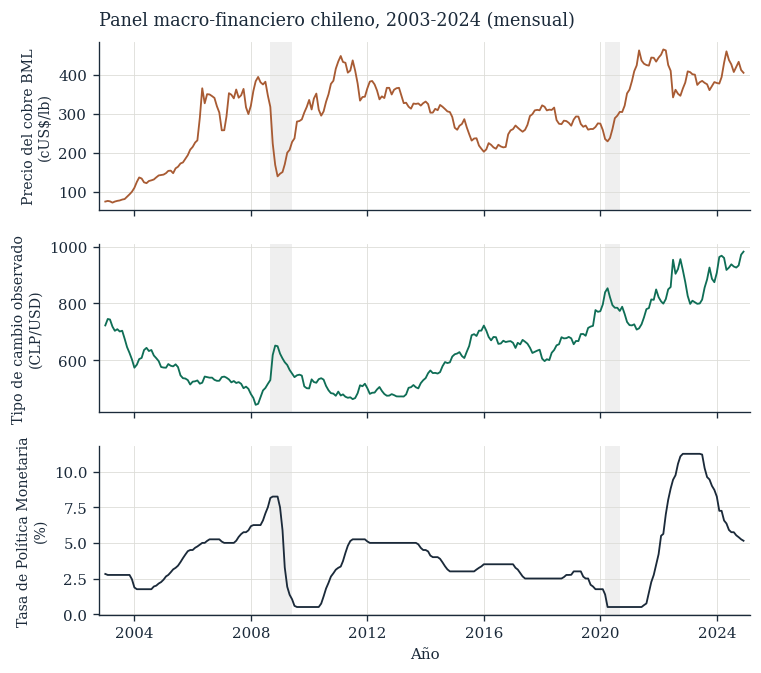

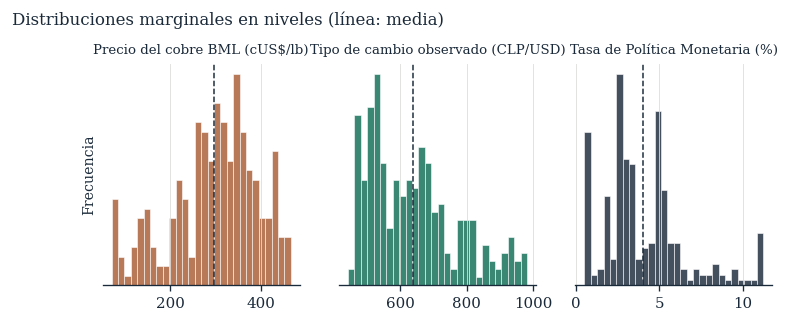

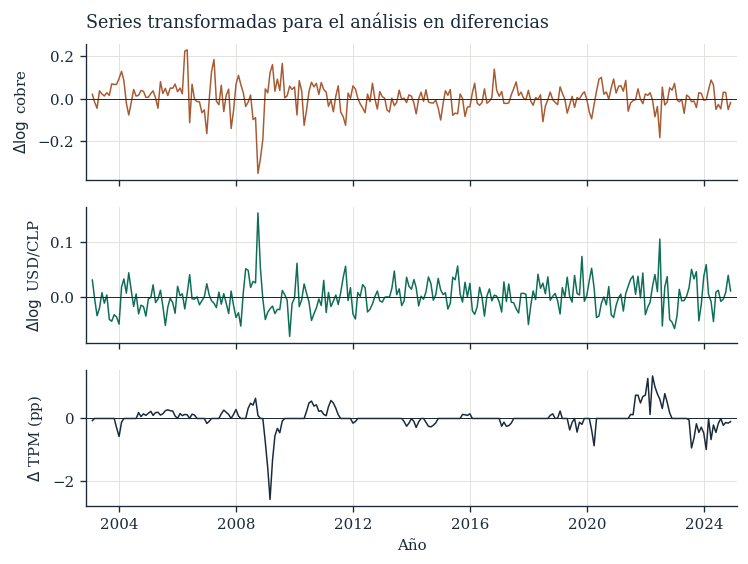

In [11]:
TINTA, COBRE, TEAL, GRIS = "#1B2A3A", "#A85B33", "#0F6E56", "#8A8A84"
COLOR = {"cobre": COBRE, "usdclp": TEAL, "tpm": TINTA}
ETIQ = {"cobre":  "Precio del cobre BML\n(cUS$/lb)",
        "usdclp": "Tipo de cambio observado\n(CLP/USD)",
        "tpm":    "Tasa de Política Monetaria\n(%)"}

plt.rcParams.update({"font.family":"serif", "font.size":9,
    "axes.edgecolor":TINTA, "axes.labelcolor":TINTA, "text.color":TINTA,
    "xtick.color":TINTA, "ytick.color":TINTA,
    "axes.spines.top":False, "axes.spines.right":False,
    "axes.grid":True, "grid.color":"#DDDDD8", "grid.linewidth":0.5,
    "figure.dpi":120, "savefig.bbox":"tight"})

# --- Series en niveles ---
fig, axes = plt.subplots(3, 1, figsize=(7.0, 6.2), sharex=True)
for ax, c in zip(axes, SERIES_N):
    ax.plot(panel.index, panel[c], color=COLOR[c], lw=1.1)
    ax.set_ylabel(ETIQ[c], fontsize=8.5); ax.margins(x=0.01)
    ax.axvspan(pd.Timestamp("2008-09-01"), pd.Timestamp("2009-06-01"), color=GRIS, alpha=.13, lw=0)
    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-09-01"), color=GRIS, alpha=.13, lw=0)
axes[0].set_title("Panel macro-financiero chileno, 2003-2024 (mensual)",
                  fontsize=10.5, loc="left", pad=10)
axes[-1].set_xlabel("Año")
fig.savefig(AQUI/"fig_series_niveles.pdf"); plt.show()

# --- Histogramas ---
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.4))
for ax, c in zip(axes, SERIES_N):
    ax.hist(panel[c], bins=28, color=COLOR[c], alpha=.82, edgecolor="white", lw=.4)
    ax.axvline(panel[c].mean(), color=TINTA, ls="--", lw=.9)
    ax.set_title(ETIQ[c].replace("\n"," "), fontsize=8)
    ax.set_yticks([]); ax.spines["left"].set_visible(False)
axes[0].set_ylabel("Frecuencia", fontsize=8.5)
fig.suptitle("Distribuciones marginales en niveles (línea: media)",
             fontsize=10, x=.02, ha="left", y=1.06)
fig.savefig(AQUI/"fig_histogramas.pdf"); plt.show()

# --- Series transformadas ---
ET_DIF = {"d_cobre":"$\\Delta \\log$ cobre", "d_usdclp":"$\\Delta \\log$ USD/CLP",
          "d_tpm":"$\\Delta$ TPM (pp)"}
fig, axes = plt.subplots(3, 1, figsize=(7.0, 5.0), sharex=True)
for ax, c in zip(axes, dif.columns):
    ax.plot(dif.index, dif[c], color=COLOR[c.replace("d_","")], lw=.9)
    ax.axhline(0, color=TINTA, lw=.6); ax.set_ylabel(ET_DIF[c], fontsize=9)
    ax.margins(x=0.01)
axes[0].set_title("Series transformadas para el análisis en diferencias",
                  fontsize=10.5, loc="left", pad=10)
axes[-1].set_xlabel("Año")
fig.savefig(AQUI/"fig_diferencias.pdf"); plt.show()

### Paso 11 — Registros de trazabilidad

**Propósito:** dejar por escrito el origen de cada dato, las decisiones tomadas y el entorno de cómputo.

| Entrada | Salida |
|---|---|
| resultados de los pasos 3, 5 y 9 | `cobertura_bcch.txt`, `registro_panel.txt` |

> **No es documentación opcional.** Son los archivos que permiten afirmar en §4.1 que la convención de agregación fue *verificada* y no supuesta, y en §4.5 que el cómputo es reproducible con versiones declaradas. Sin ellos, ambas afirmaciones quedan sin respaldo.

In [12]:
reg1 = ["REGISTRO DE DESCARGA - API BDE Banco Central de Chile",
        f"Generado: {pd.Timestamp.now():%Y-%m-%d %H:%M}",
        f"Ventana : {INICIO} a {FIN}", "", "Series:"]
for n, sid in SERIES.items():
    reg1 += [f"  {n:8s} {sid}", f"           {titulos.get(n,'')}"]
reg1 += ["", "Verificacion de agregacion (tipo de cambio mensual):",
         f"  Error absoluto medio vs promedio del mes : {e_prom:.6f} CLP",
         f"  Error absoluto medio vs cierre del mes   : {e_cierre:.6f} CLP",
         f"  Conclusion: {veredicto}"]
(AQUI/"cobertura_bcch.txt").write_text("\n".join(reg1), encoding="utf-8")

reg2 = ["REGISTRO DE CONSTRUCCION DEL PANEL",
        f"Generado: {pd.Timestamp.now():%Y-%m-%d %H:%M}", "", "Fuentes:",
        "  cobre  Cochilco, precio del cobre refinado mensual, columna BML",
        "         (cUS$/lb), nominal. Archivo historico actualizado al ano 2024.",
        f"  usdclp Banco Central de Chile, {SERIES['usdclp']}, promedio mensual.",
        f"  tpm    Banco Central de Chile, {SERIES['tpm']}, promedio simple.", "",
        "Convencion de agregacion: las tres series son promedios mensuales.",
        "La de usdclp fue verificada por doble via contra la serie diaria.", "",
        f"Dimensiones: {panel.shape[0]} meses x {panel.shape[1]} series",
        f"Ventana: {panel.index.min():%Y-%m} a {panel.index.max():%Y-%m}",
        f"Valores faltantes: {int(panel.isna().sum().sum())}", "",
        "Transformaciones para el analisis en diferencias:",
        "  cobre, usdclp -> diferencia de logaritmos (retornos)",
        "  tpm           -> diferencia simple (ya en puntos porcentuales)",
        f"Orden de rezagos Granger (BIC sobre VAR trivariado): {LAG}", "",
        "Entorno de calculo:",
        f"  python {sys.version.split()[0]}  numpy {np.__version__}  pandas {pd.__version__}",
        f"  statsmodels {statsmodels.__version__}  scipy {scipy.__version__}"]
(AQUI/"registro_panel.txt").write_text("\n".join(reg2), encoding="utf-8")

print("\n".join(reg2))

REGISTRO DE CONSTRUCCION DEL PANEL
Generado: 2026-09-17 16:13

Fuentes:
  cobre  Cochilco, precio del cobre refinado mensual, columna BML
         (cUS$/lb), nominal. Archivo historico actualizado al ano 2024.
  usdclp Banco Central de Chile, F073.TCO.PRE.HIST.M, promedio mensual.
  tpm    Banco Central de Chile, F022.TPM.TIN.D001.NO.Z.M, promedio simple.

Convencion de agregacion: las tres series son promedios mensuales.
La de usdclp fue verificada por doble via contra la serie diaria.

Dimensiones: 264 meses x 3 series
Ventana: 2003-01 a 2024-12
Valores faltantes: 0

Transformaciones para el analisis en diferencias:
  cobre, usdclp -> diferencia de logaritmos (retornos)
  tpm           -> diferencia simple (ya en puntos porcentuales)
Orden de rezagos Granger (BIC sobre VAR trivariado): 1

Entorno de calculo:
  python 3.12.3  numpy 2.4.4  pandas 3.0.2
  statsmodels 0.15.0  scipy 1.17.1


---

## Lectura de los resultados

**El panel está completo**: 264 de 264 meses, sin valores faltantes en ninguna de las tres series.

**La convención de agregación quedó establecida por evidencia, no por supuesto.** La diferencia entre ambos candidatos es de cuatro órdenes de magnitud, de modo que las tres series comparten el mismo criterio de promedio mensual sin necesidad de transformaciones propias.

**El panel es de orden de integración mixto.** Cobre y tipo de cambio se comportan como $I(1)$; la TPM rechaza la raíz unitaria al 5 %. Esto matiza la afirmación del avance anterior de que el régimen $I(1)$ era plenamente representativo del caso chileno, y constituye una predicción contrastable adicional: el beneficio de $R_G$ podría manifestarse de forma heterogénea entre series.

**La evidencia sobre la cadena causal es de dos signos.** La correlación contemporánea entre los retornos del cobre y del tipo de cambio es intensa y del signo esperado, pero ninguna de las dos flechas del ordenamiento supuesto resulta significativa en precedencia mensual. En consecuencia, $\Pi(G)$ se sostiene como estructura de dependencia contemporánea y de mediano plazo, no como precedencia mes a mes. La máscara de causalidad temporal del modelo es compatible con esa lectura: bloquea el futuro y deja libre la atención contemporánea.

**Siguiente paso:** `panel_2003_2024.csv` es la entrada del cuaderno de evaluación de líneas base.